# Continental-scale Animations <img align="right" src="../Supplementary_data/dea_logo.jpg">

* **[Sign up to the DEA Sandbox](https://app.sandbox.dea.ga.gov.au/)** to run this notebook interactively from a browser
* **Compatability:** Notebook currently compatible with the `DEA Sandbox` environment
* **Products used:** 
[ga_ls8cls9c_gm_cyear_3](https://explorer.dea.ga.gov.au/ga_ls8cls9c_gm_cyear_3)

## Background

Using the DEA function `xr_animaton`, which is based on `matplotlib.animation` and `xarray`, we can take a time series of Digital Earth Australia's [geomedian](https://github.com/GeoscienceAustralia/dea-notebooks/blob/develop/DEA_products/DEA_GeoMAD.ipynb) satellite imagery and export a visually appealing time series animation for the **entire Australian continent**.

Animations can be a powerful method for visualising change in the landscape across time using satellite imagery. Satellite data from Digital Earth Australia is an ideal subject for animations as it has been georeferenced, processed to analysis-ready surface reflectance, and stacked into a spatio-temporal 'data cube', allowing landscape conditions to be extracted and  visualised consistently across time.



## Description
This notebook demonstrates how to:

1. Import a time series of Landsat 8 and 9 geomedians
2. Export true colour animations

***

## Getting started
To run this analysis, run all the cells in the notebook, starting with the "Load packages" cell. 

### Load packages

In [1]:
%matplotlib inline
import sys
import datacube
import matplotlib.pyplot as plt
from IPython.display import Image

sys.path.insert(1, "../Tools/")
from dea_tools.plotting import xr_animation, rgb
from dea_tools.bandindices import calculate_indices
from dea_tools.dask import create_local_dask_cluster

In [2]:
create_local_dask_cluster()

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/chad.burton@ga.gov.au/proxy/8787/status,
Dashboard: /user/chad.burton@ga.gov.au/proxy/8787/status,Workers: 1
Total threads: 2,Total memory: 12.21 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:33631,Workers: 1
Dashboard: /user/chad.burton@ga.gov.au/proxy/8787/status,Total threads: 2
Started: Just now,Total memory: 12.21 GiB
Comm: tcp://127.0.0.1:33613,Total threads: 2
Dashboard: /user/chad.burton@ga.gov.au/proxy/38265/status,Memory: 12.21 GiB
Nanny: tcp://127.0.0.1:45949,


### Connect to the datacube

In [3]:
dc = datacube.Datacube(app='export_animated_timeseries')

## Load satellite data from datacube
We will use the `dc.load` function to load the geomedian data, and return an `xarray.Dataset`. 
This will allow us to create a visually appealing time series animation of observations for the selected time. In the default example, we only load two years of data to reduce the loading time.

**NOTE: This cell takes approximately 12 minutes to run with the default sandbox.**

In [4]:
#Specify the time period
time_range = ('2023', '2024')

# Load geomedian data
ds = dc.load(product='ga_ls8cls9c_gm_cyear_3',
             measurements=["nbart_red", "nbart_green", "nbart_blue"],
             output_crs='epsg:3577',
             time = time_range,
             resolution=(-5000, 5000), # coarse-scale resolution
             resampling={'*':'bilinear'},
             dask_chunks=dict(x=500,y=250, time=1)
              )

#remove no-data values
ds = ds.where(ds>0)

# bring into memory
ds.load()

/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


<xarray.Dataset> Size: 16MB
Dimensions:      (time: 2, y: 788, x: 846)
Coordinates:
  * time         (time) datetime64[ns] 16B 2023-07-02T11:59:59.999999 2024-07...
  * y            (y) float64 6kB -9.625e+05 -9.675e+05 ... -4.892e+06 -4.898e+06
  * x            (x) float64 7kB -2.018e+06 -2.012e+06 ... 2.202e+06 2.208e+06
    spatial_ref  int32 4B 3577
Data variables:
    nbart_red    (time, y, x) float32 5MB nan nan nan nan ... nan nan nan nan
    nbart_green  (time, y, x) float32 5MB nan nan nan nan ... nan nan nan nan
    nbart_blue   (time, y, x) float32 5MB nan nan nan nan ... nan nan nan nan
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

## Animate the RGB time series

To learn more about the customising the `xr_animation` function, see the [Animated_timeseries.ipynb](https://github.com/GeoscienceAustralia/dea-notebooks/blob/develop/How_to_guides/Animated_timeseries.ipynb) notebook.

Exporting animation to rgb_continental_timeseries.gif


  0%|          | 0/2 (0.0 seconds remaining at ? frames/s)

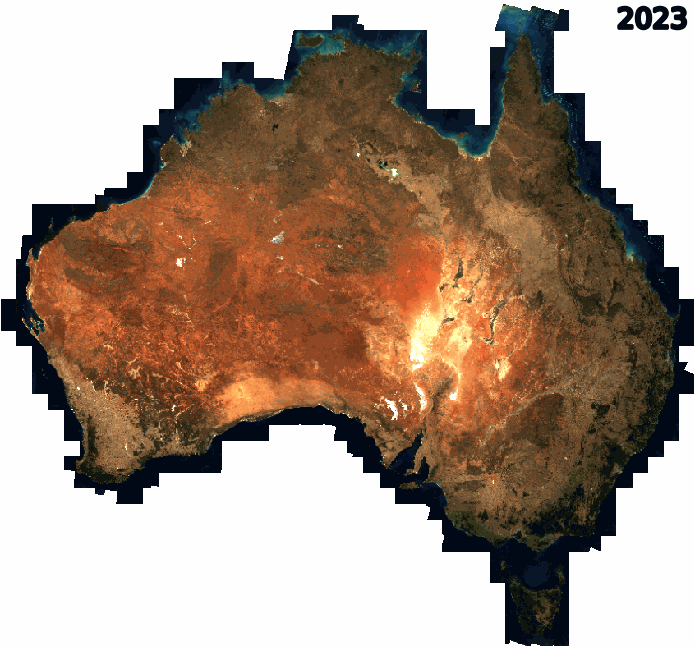

In [5]:
# Produce the time series animation
xr_animation(ds=ds, 
             output_path='rgb_continental_timeseries.gif',
             bands=["nbart_red", "nbart_green", "nbart_blue"],  
             show_date='%Y',
             interval=600,
             percentile_stretch=(0.01, 0.99),
             colorbar_kwargs={'colors': 'black'},
             width_pixels=500,
             annotation_kwargs= {'color':'black', 'animated': True}
    ) 

# Plot animated gif
plt.close()
Image(filename='rgb_continental_timeseries.gif')

***

## Additional information

**License:** The code in this notebook is licensed under the [Apache License, Version 2.0](https://www.apache.org/licenses/LICENSE-2.0). 
Digital Earth Australia data is licensed under the [Creative Commons by Attribution 4.0](https://creativecommons.org/licenses/by/4.0/) license.

**Contact:** If you need assistance, please post a question on the [Open Data Cube Discord chat](https://discord.com/invite/4hhBQVas5U) or on the [GIS Stack Exchange](https://gis.stackexchange.com/questions/ask?tags=open-data-cube) using the `open-data-cube` tag (you can view previously asked questions [here](https://gis.stackexchange.com/questions/tagged/open-data-cube)).
If you would like to report an issue with this notebook, you can file one on [GitHub](https://github.com/GeoscienceAustralia/dea-notebooks).

**Last modified:** April 2025

**Compatible datacube version:** 

In [6]:
print(datacube.__version__)

1.8.19


## Tags
<!-- Browse all available tags on the DEA User Guide's [Tags Index](https://knowledge.dea.ga.gov.au/genindex/) -->